# Scorer comparison: summary vs benchmark + why-good/why-bad detail

Runs multiple scorer configs through the vectorized alpha layer
(`src2/alpha_engine.py` + `src2/run_vectorized.py`), then:

1. **Summary**: one metrics table (CAGR/Sharpe/Sortino/MaxDD/Calmar) for
   every scorer + benchmark, plus a rebased performance chart.
2. **Detail**: for each scorer, an Information Coefficient time series
   (did the score actually predict forward return each period?) and a
   per-ticker contribution breakdown (what actually drove the result),
   computed directly off `df_ranked` -- no trade-log parsing needed.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd

from src import data_broker, calendar_iterator, metrics, analysis
from src2 import vectorized_scorers, alpha_engine, run_vectorized, evaluation

## 1. Data: universe + benchmark

In [2]:
tickers = 'ALGN,AAPL,PANW,AMD,ZS,MDLZ,XEL,VRSN,INSM,ON,WDAY,ENPH,DLTR,ADI,COST,ABNB,CEG,MSFT,GOOGL,CDNS,PYPL,FAST,JD,MTCH,SNPS,LULU,CMCSA,ADBE,ADSK'.split(',')

broker = data_broker.DataBroker(tickers=tickers, start_date="2022-01-01", end_date="2026-04-01")
universe_data = broker.fetch_universe_data()
price_df = universe_data['price']

bench_broker = data_broker.DataBroker(tickers=['SPY', 'QQQ'], start_date="2022-01-01", end_date="2026-04-01")
bench_price = bench_broker.fetch_universe_data()['price']

[*********************100%***********************]  29 of 29 completed
[*********************100%***********************]  2 of 2 completed


In [3]:
calendar = calendar_iterator.CalendarIterator(universe_data, interval="ME")
rebalance_dates = calendar.generate_rebalance_dates()
len(rebalance_dates)

51

## 2. Define the scorer configs to compare

In [4]:
SCORER_CONFIGS = {
    "mean_reversion_60d": dict(score_fn=vectorized_scorers.rolling_mean_reversion_score, window=60),
    "mean_reversion_20d": dict(score_fn=vectorized_scorers.rolling_mean_reversion_score, window=20),
    "geometric_drift_126d": dict(score_fn=vectorized_scorers.rolling_geometric_drift_score, window=126),
    "geometric_drift_252d": dict(score_fn=vectorized_scorers.rolling_geometric_drift_score, window=252),
}

## 3. Run every config

In [5]:
results = {}
for name, cfg in SCORER_CONFIGS.items():
    score_fn = cfg.pop("score_fn")
    df_metrics, df_ranked = alpha_engine.build_target_weight_table(
        price_df, rebalance_dates, score_fn=score_fn, top_percent=0.25, allocation_type="equal", **cfg,
    )
    g_state, audit_ledger = run_vectorized.run_vectorized(df_ranked, universe_data, rebalance_dates)
    df_nav = g_state.export_nav_dataframe()[['Total_NAV']].rename(columns={'Total_NAV': name})
    results[name] = {"df_metrics": df_metrics, "df_ranked": df_ranked, "df_nav": df_nav}
    cfg["score_fn"] = score_fn  # restore for re-run safety

list(results.keys())

[2026-07-24 10:15:55] INFO [backtest_logger]:     2022-02-01 00:00:00:CORE_BUY VRSN ... 66.74@213.61, fee: 14.27
[2026-07-24 10:15:55] INFO [backtest_logger]:     2022-02-01 00:00:00:CORE_BUY MTCH ... 132.47@107.62, fee: 14.27
[2026-07-24 10:15:55] INFO [backtest_logger]:     2022-02-01 00:00:00:CORE_BUY ALGN ... 28.03@508.56, fee: 14.27
[2026-07-24 10:15:55] INFO [backtest_logger]:     2022-02-01 00:00:00:CORE_BUY DLTR ... 106.21@134.24, fee: 14.27
[2026-07-24 10:15:55] INFO [backtest_logger]:     2022-02-01 00:00:00:CORE_BUY FAST ... 560.16@25.45, fee: 14.27
[2026-07-24 10:15:55] INFO [backtest_logger]:     2022-02-01 00:00:00:CORE_BUY AMD ... 122.09@116.78, fee: 14.27
[2026-07-24 10:15:55] INFO [backtest_logger]:     2022-02-01 00:00:00:CORE_BUY CDNS ... 94.04@151.61, fee: 14.27
[2026-07-24 10:15:55] INFO [backtest_logger]:     2022-03-01 00:00:00:CORE_SELL VRSN ... 66.74@212.81, fee: 14.2
[2026-07-24 10:15:55] INFO [backtest_logger]:     2022-03-01 00:00:00:CORE_SELL MTCH ... 132.4

['mean_reversion_60d',
 'mean_reversion_20d',
 'geometric_drift_126d',
 'geometric_drift_252d']

## 4. Summary: metrics table + rebased performance vs benchmark

In [8]:
df_nav_all_ = pd.concat([bench_price[['SPY', 'QQQ']]] + [r["df_nav"] for r in results.values()], axis=1).dropna(how='all')
df_nav_all=df_nav_all_.loc[df_nav_all_.index>='2023-01-01']

In [9]:
df_nav_all = df_nav_all.ffill()
metrics.calculate_metrics(df_nav_all)

,CAGR,Sharpe_Ratio,Sortino_Ratio,Max_Drawdown,Calmar_Ratio
SPY,0.195150,1.503748,2.521017,0.187552,1.040511
QQQ,0.279988,1.622094,2.757982,0.227683,1.229725
mean_reversion_60d,0.129926,0.761713,1.307233,0.226510,0.573600
mean_reversion_20d,0.023717,0.261644,0.425787,0.336481,0.070485
geometric_drift_126d,0.097746,0.645487,1.040003,0.275835,0.354364
geometric_drift_252d,0.121097,0.778174,1.273133,0.261420,0.463228


In [11]:
df_nav_all_ = df_nav_all_.ffill()
metrics.calculate_metrics(df_nav_all_)

,CAGR,Sharpe_Ratio,Sortino_Ratio,Max_Drawdown,Calmar_Ratio
SPY,0.090406,0.694484,1.142379,0.244964,0.369059
QQQ,0.096121,0.614870,1.015632,0.348280,0.275987
mean_reversion_60d,0.074223,0.480602,0.834211,0.248109,0.299154
mean_reversion_20d,-0.005418,0.138821,0.232085,0.336481,-0.016101
geometric_drift_126d,0.051662,0.411421,0.664412,0.275835,0.187292
geometric_drift_252d,0.091285,0.680090,1.072631,0.261420,0.349187


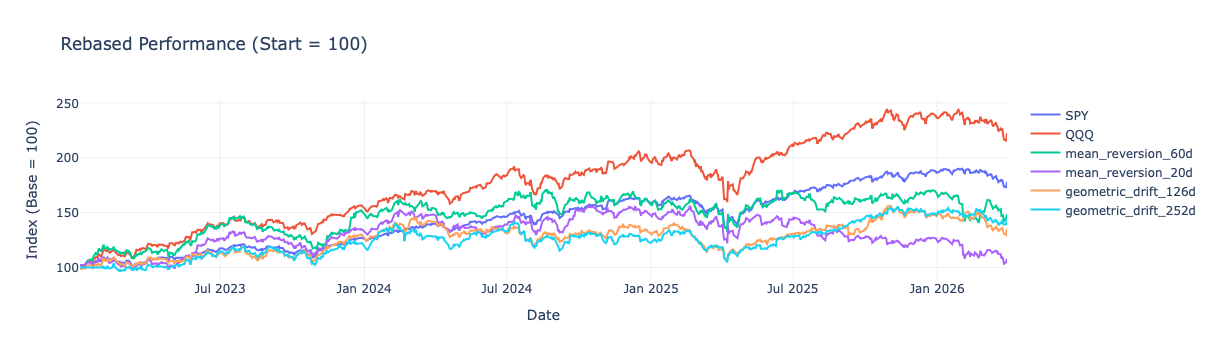

In [12]:
analysis.plot_rebased_performance(df_nav_all)

## 5. Detail: Information Coefficient per scorer

Spearman correlation between that period's score and the ticker's actual
forward return, per rebalance date. Consistently near/below 0 across the
whole run means the score isn't predicting anything -- a strong signal the
strategy failing isn't a fee/execution problem, it's the scorer itself.

In [8]:
ic_summary = {}
for name, r in results.items():
    df_fwd = evaluation.add_forward_return(r["df_ranked"], price_df, rebalance_dates)
    df_ic = evaluation.information_coefficient(df_fwd)
    results[name]["df_fwd"] = df_fwd
    results[name]["df_ic"] = df_ic
    ic_summary[name] = df_ic["ic"].mean()

pd.Series(ic_summary, name="mean_IC").sort_values(ascending=False)

mean_reversion_60d      0.019302
geometric_drift_252d    0.016127
geometric_drift_126d    0.010558
mean_reversion_20d      0.001129
Name: mean_IC, dtype: float64

## 6. Detail: per-ticker contribution -- what actually drove each scorer's result

In [9]:
best_scorer = pd.Series(ic_summary).idxmax()
worst_scorer = pd.Series(ic_summary).idxmin()
print(f"best by IC: {best_scorer}   worst by IC: {worst_scorer}")

evaluation.contribution_by_ticker(results[worst_scorer]["df_fwd"]).head(10)

best by IC: mean_reversion_60d   worst by IC: mean_reversion_20d


,total_contribution,n_periods_held,avg_weight_when_held
ticker,,,
PANW,0.113856,14,0.142857
JD,0.076728,23,0.142857
ADSK,0.062273,12,0.142857
ADI,0.058429,5,0.142857
GOOGL,0.051335,12,0.142857
ALGN,0.046295,15,0.142857
INSM,0.046271,10,0.142857
ABNB,0.040568,14,0.142857
FAST,0.037117,9,0.142857


In [10]:
evaluation.contribution_by_ticker(results[worst_scorer]["df_fwd"]).tail(10)

,total_contribution,n_periods_held,avg_weight_when_held
ticker,,,
PYPL,-0.012223,9,0.142857
CEG,-0.013790,10,0.142857
MSFT,-0.018313,14,0.142857
SNPS,-0.031331,7,0.142857
MDLZ,-0.035767,16,0.142857
MTCH,-0.050029,10,0.142857
DLTR,-0.068896,11,0.142857
WDAY,-0.072738,16,0.142857
ENPH,-0.090459,19,0.142857


## 7. Detail: turnover per scorer (trading intensity / fee drag proxy)

In [11]:
turnover_summary = {
    name: evaluation.turnover_by_date(r["df_ranked"]).mean()
    for name, r in results.items()
}
pd.Series(turnover_summary, name="avg_turnover_per_rebalance").sort_values(ascending=False)

mean_reversion_20d      1.428571
mean_reversion_60d      1.243697
geometric_drift_126d    0.585434
geometric_drift_252d    0.355742
Name: avg_turnover_per_rebalance, dtype: float64

## 8. Does IC improve? Window sweep + blended composite score

In [12]:
def quick_ic(score_fn, **kwargs):
    _, df_ranked = alpha_engine.build_target_weight_table(
        price_df, rebalance_dates, score_fn=score_fn, top_percent=0.25, allocation_type="equal", **kwargs,
    )
    df_fwd = evaluation.add_forward_return(df_ranked, price_df, rebalance_dates)
    return evaluation.information_coefficient(df_fwd)["ic"].mean()

sweep = {}
for w in [10, 20, 40, 60, 90, 120]:
    sweep[f"mean_reversion_{w}d"] = quick_ic(vectorized_scorers.rolling_mean_reversion_score, window=w, min_periods=min(20, w))
for w in [21, 63, 126, 189, 252]:
    sweep[f"geometric_drift_{w}d"] = quick_ic(vectorized_scorers.rolling_geometric_drift_score, window=w)

pd.Series(sweep, name="mean_IC").sort_values(ascending=False)

mean_reversion_40d      0.024598
geometric_drift_21d     0.020127
mean_reversion_60d      0.019302
mean_reversion_90d      0.018799
mean_reversion_10d      0.016946
geometric_drift_252d    0.016127
geometric_drift_126d    0.010558
mean_reversion_120d     0.006974
mean_reversion_20d      0.001129
geometric_drift_189d   -0.011366
geometric_drift_63d    -0.032732
Name: mean_IC, dtype: float64

In [13]:
composite_sweep = {}
for mom_w in [0.0, 0.25, 0.5, 0.75, 1.0]:
    composite_sweep[f"composite_mom{mom_w}"] = quick_ic(
        vectorized_scorers.rolling_composite_score,
        momentum_window=252, reversion_window=60, momentum_weight=mom_w,
    )

pd.Series(composite_sweep, name="mean_IC").sort_values(ascending=False)

composite_mom0.5     0.022671
composite_mom1.0     0.016127
composite_mom0.25    0.015054
composite_mom0.75    0.011927
composite_mom0.0     0.008104
Name: mean_IC, dtype: float64

## 9. Is the IC statistically distinguishable from zero, or just noise?

In [14]:
sig_rows = {}
for name, r in results.items():
    sig_rows[name] = evaluation.ic_significance(r["df_ic"])

pd.DataFrame(sig_rows).T

,mean_ic,std_ic,n_dates,t_stat,p_value
mean_reversion_60d,0.019302,0.202375,50.0,0.674434,0.503205
mean_reversion_20d,0.001129,0.216157,50.0,0.036936,0.970686
geometric_drift_126d,0.010558,0.241252,44.0,0.290280,0.772997
geometric_drift_252d,0.016127,0.261686,38.0,0.379885,0.706203
